<a href="https://colab.research.google.com/github/Prathama-1/Prosperity-4---Solo42/blob/main/Round4_dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ─── CELL 1: Installs & Imports ────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import norm, pearsonr
from scipy.optimize import brentq
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid", palette="tab10")
plt.rcParams["figure.dpi"] = 120

In [2]:
# ─── CELL 2: Load Data ─────────────────────────────────────────────────────

p1 = pd.read_csv("prices_round_4_day_1.csv", sep=";")
p2 = pd.read_csv("prices_round_4_day_2.csv", sep=";")
p3 = pd.read_csv("prices_round_4_day_3.csv", sep=";")
t1 = pd.read_csv("trades_round_4_day_1.csv", sep=";")
t2 = pd.read_csv("trades_round_4_day_2.csv", sep=";")
t3 = pd.read_csv("trades_round_4_day_3.csv", sep=";")

t1["day"] = 1; t2["day"] = 2; t3["day"] = 3
prices = pd.concat([p1, p2, p3], ignore_index=True)
trades = pd.concat([t1, t2, t3], ignore_index=True)

# Create a global time index  (day * 1_000_000 + timestamp)
prices["global_ts"] = prices["day"] * 1_000_000 + prices["timestamp"]
trades["global_ts"] = trades["day"] * 1_000_000 + trades["timestamp"]

PRODUCTS   = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]
VEV_STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VEV_NAMES   = [f"VEV_{k}" for k in VEV_STRIKES]
ALL_MARKS   = sorted(set(trades["buyer"].unique()) | set(trades["seller"].unique()))

print("Products in prices:", prices["product"].unique().tolist())
print("Unique Marks:", ALL_MARKS)
print(f"Price rows: {len(prices):,}   Trade rows: {len(trades):,}")

Products in prices: ['VELVETFRUIT_EXTRACT', 'HYDROGEL_PACK', 'VEV_6000', 'VEV_5000', 'VEV_6500', 'VEV_5300', 'VEV_5400', 'VEV_4000', 'VEV_5100', 'VEV_5200', 'VEV_5500', 'VEV_4500']
Unique Marks: ['Mark 01', 'Mark 14', 'Mark 22', 'Mark 38', 'Mark 49', 'Mark 55', 'Mark 67']
Price rows: 360,000   Trade rows: 4,281



=== MID PRICE STATS PER PRODUCT ===
                        mean    std     min      max
product                                             
HYDROGEL_PACK        9994.65  34.62  9891.0  10081.0
VELVETFRUIT_EXTRACT  5247.65  18.08  5191.5   5300.0
VEV_4000             1247.66  18.10  1189.0   1302.0
VEV_4500              747.66  18.09   690.5    800.5
VEV_5000              251.14  17.46   196.5    301.5
VEV_5100              160.86  16.13   111.5    205.5
VEV_5200               88.99  13.35    51.0    122.5
VEV_5300               41.18   9.14    18.0     61.0
VEV_5400               12.63   4.15     3.5     23.0
VEV_5500                4.71   2.21     0.5     10.0
VEV_6000                0.50   0.00     0.5      0.5
VEV_6500                0.50   0.00     0.5      0.5


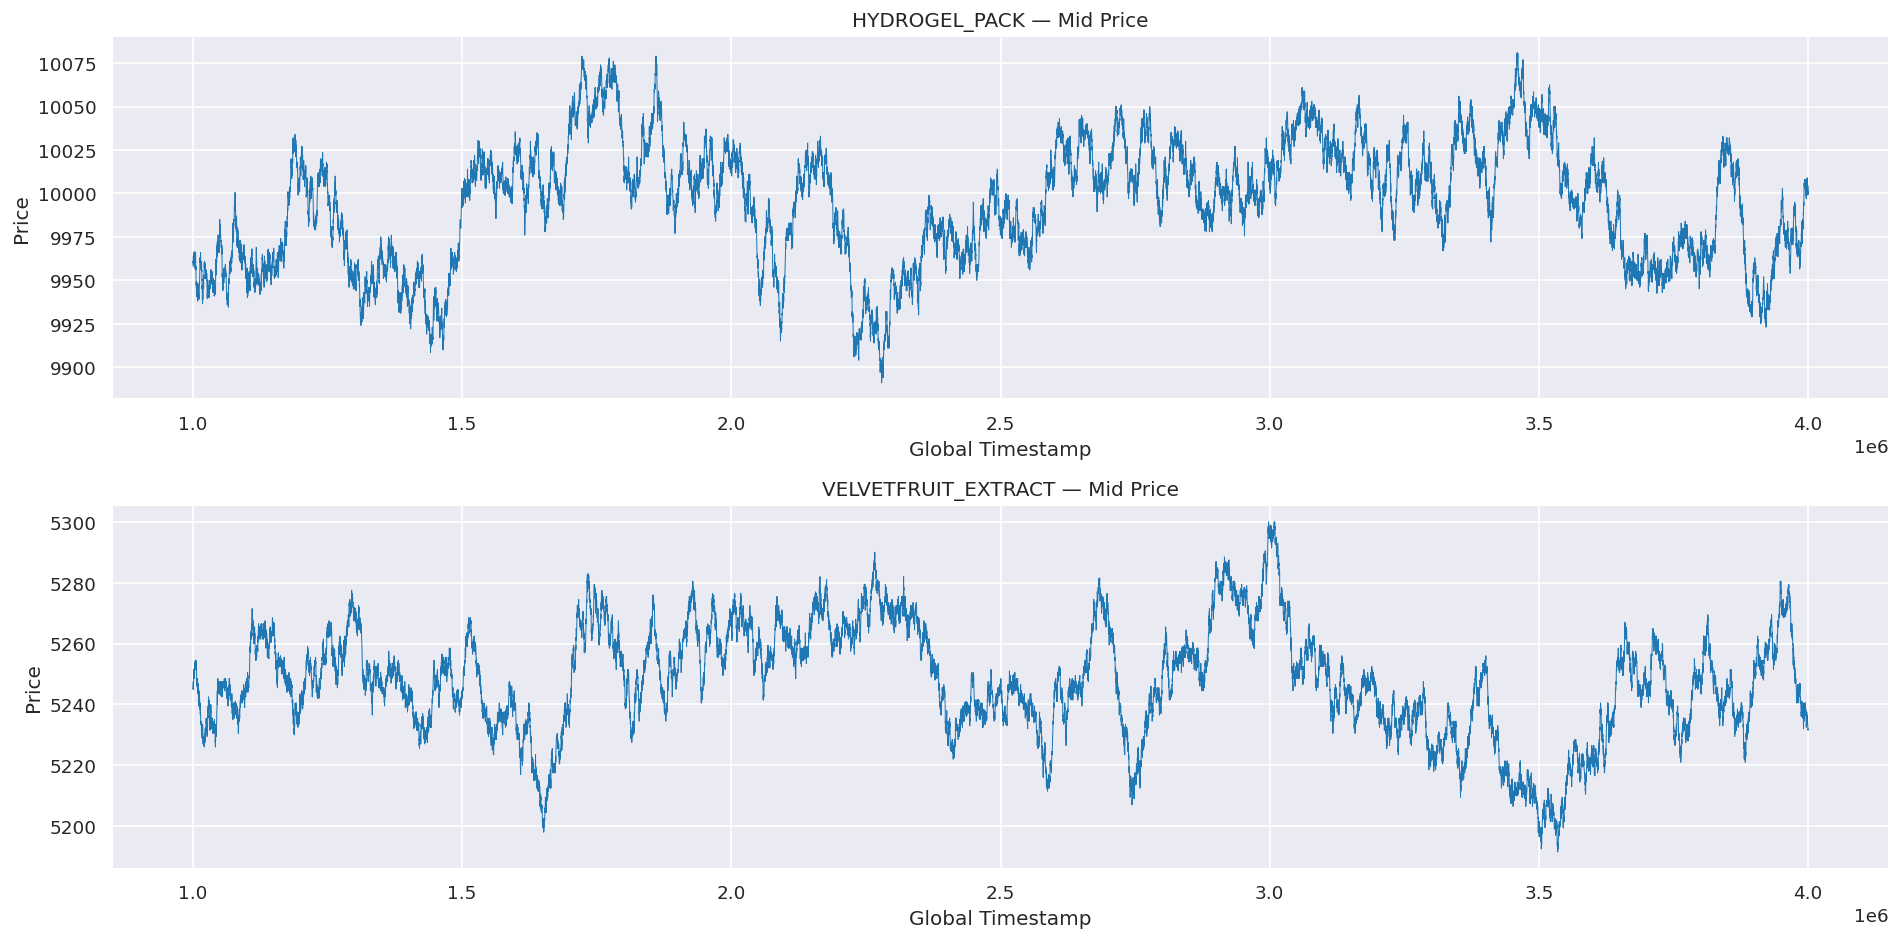

In [3]:
# ─── CELL 3: Price Overview ────────────────────────────────────────────────
print("\n=== MID PRICE STATS PER PRODUCT ===")
print(prices.groupby("product")["mid_price"]
      .agg(["mean", "std", "min", "max"]).round(2).to_string())

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)
for ax, prod in zip(axes, ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]):
    df = prices[prices["product"] == prod].sort_values("global_ts")
    ax.plot(df["global_ts"], df["mid_price"], linewidth=0.6)
    ax.set_title(f"{prod} — Mid Price")
    ax.set_xlabel("Global Timestamp"); ax.set_ylabel("Price")
plt.tight_layout(); plt.show()

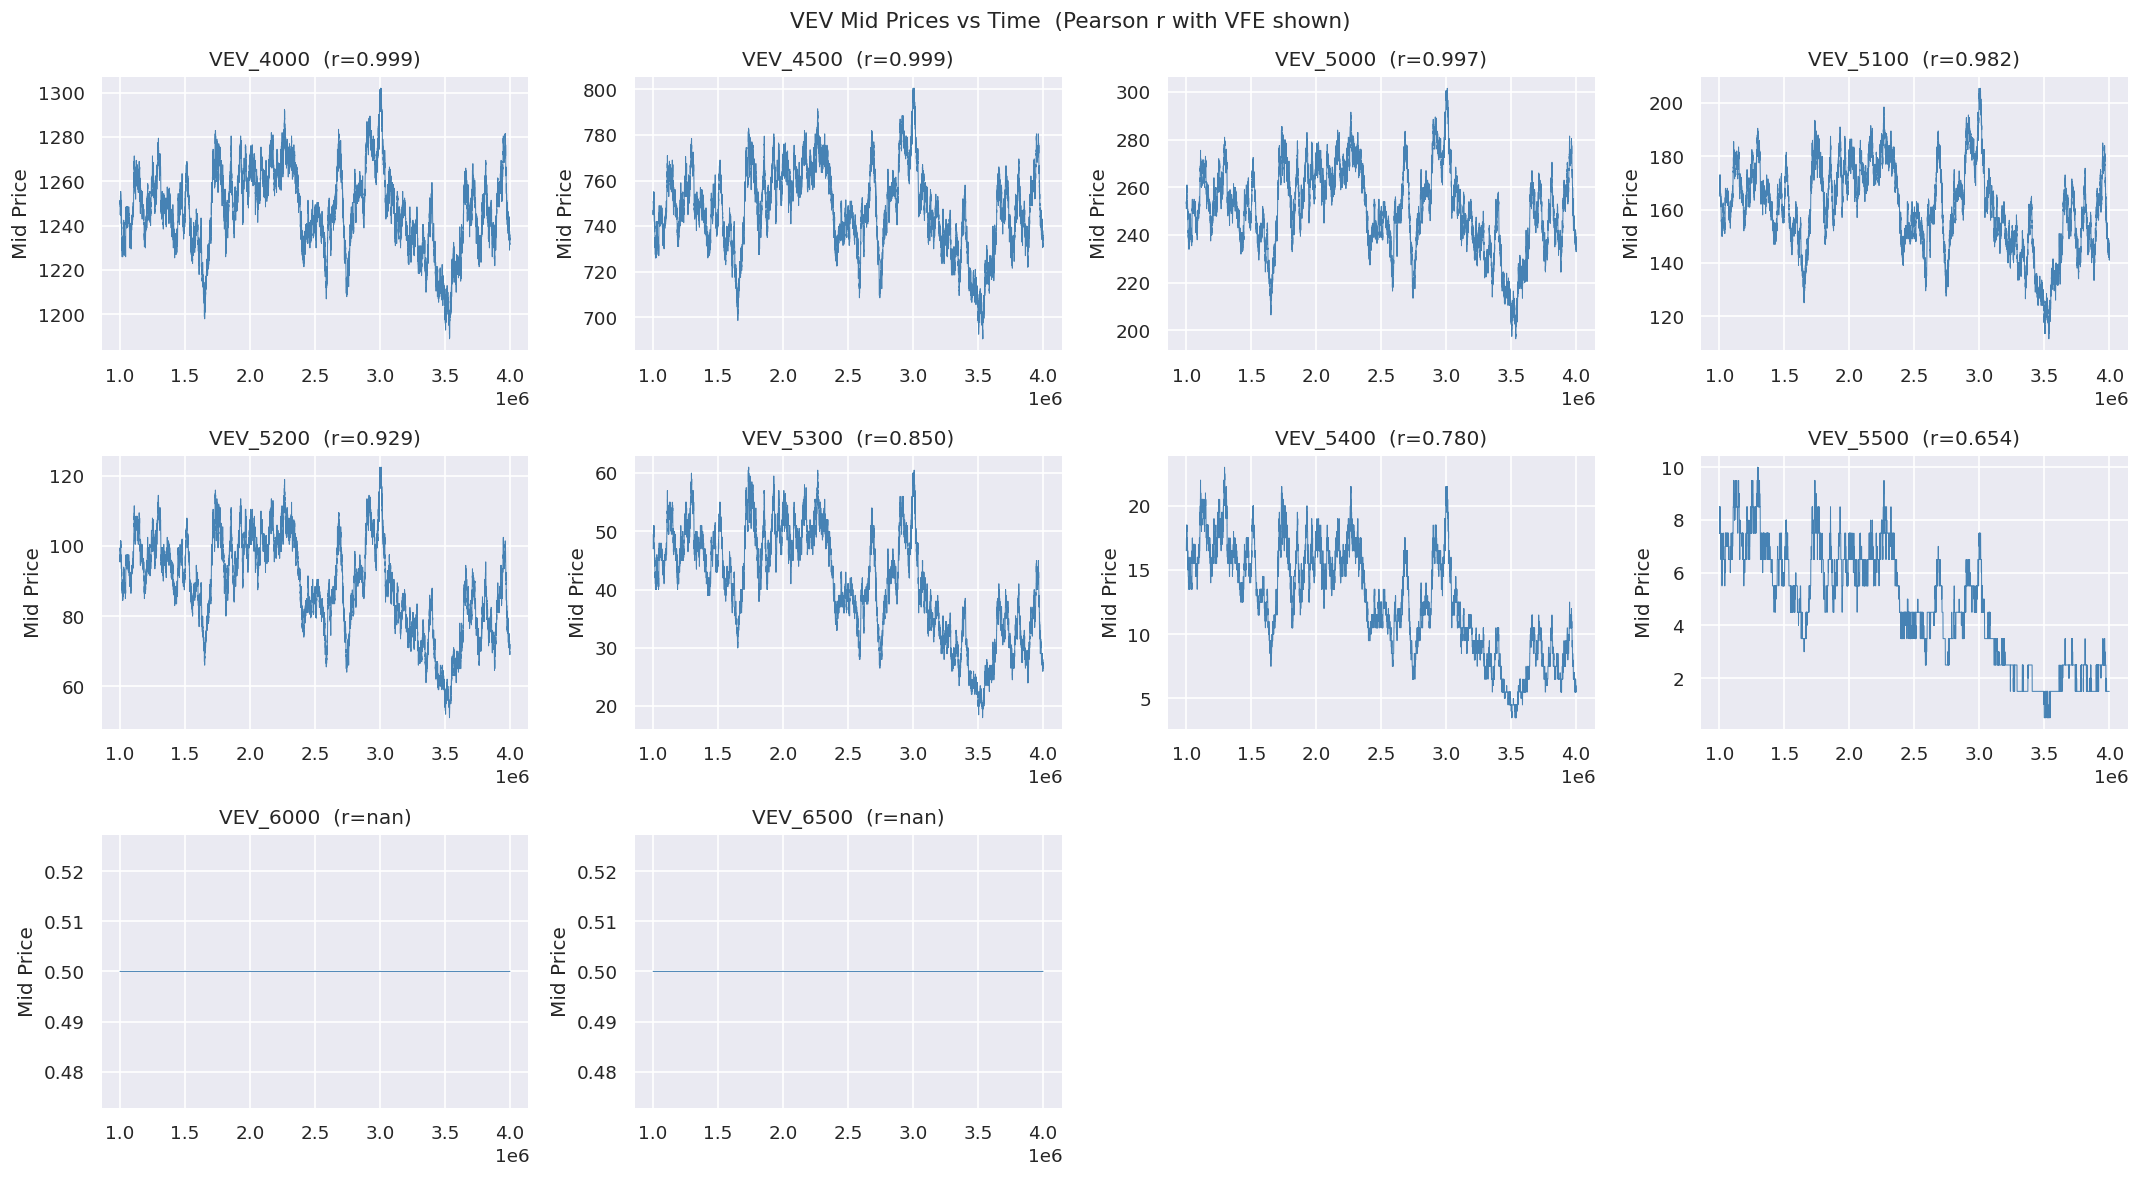


=== VFE vs VEV Pearson r ===
  VEV_4000: r = 0.9989
  VEV_4500: r = 0.9991
  VEV_5000: r = 0.9969
  VEV_5100: r = 0.9818
  VEV_5200: r = 0.9287
  VEV_5300: r = 0.8500
  VEV_5400: r = 0.7796
  VEV_5500: r = 0.6541
  VEV_6000: r = nan
  VEV_6500: r = nan


In [4]:
# ─── CELL 4: VEV Mid Prices + Correlation with VFE ────────────────────────
vfe_ts = (prices[prices["product"] == "VELVETFRUIT_EXTRACT"]
          .sort_values("global_ts")[["global_ts", "mid_price"]]
          .rename(columns={"mid_price": "vfe"}))

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()
for i, K in enumerate(VEV_STRIKES):
    vev_ts = (prices[prices["product"] == f"VEV_{K}"]
              .sort_values("global_ts")[["global_ts", "mid_price"]]
              .rename(columns={"mid_price": f"vev_{K}"}))
    m = vfe_ts.merge(vev_ts, on="global_ts")
    axes[i].plot(m["global_ts"], m[f"vev_{K}"], linewidth=0.6, color="steelblue")
    r, _ = pearsonr(m["vfe"], m[f"vev_{K}"])
    axes[i].set_title(f"VEV_{K}  (r={r:.3f})")
    axes[i].set_xlabel(""); axes[i].set_ylabel("Mid Price")
# hide extra subplots
for j in range(i+1, len(axes)): axes[j].set_visible(False)
fig.suptitle("VEV Mid Prices vs Time  (Pearson r with VFE shown)", fontsize=13)
plt.tight_layout(); plt.show()

print("\n=== VFE vs VEV Pearson r ===")
for K in VEV_STRIKES:
    vev_ts = (prices[prices["product"] == f"VEV_{K}"]
              [["global_ts", "mid_price"]].rename(columns={"mid_price": f"vev_{K}"}))
    m = vfe_ts.merge(vev_ts, on="global_ts")
    r, _ = pearsonr(m["vfe"], m[f"vev_{K}"])
    print(f"  VEV_{K}: r = {r:.4f}")


In [5]:
# ─── CELL 5: Historical Volatility & Black-Scholes Implied Vols ───────────
def bs_call(S, K, T, sigma, r=0.0):
    if T <= 0 or sigma <= 0:
        return float(max(S - K, 0))
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def implied_vol(S, K, T, market_price, r=0.0):
    if market_price <= max(S - K, 0) + 1e-6:
        return 0.0
    try:
        return brentq(lambda sig: bs_call(S, K, T, sig, r) - market_price, 1e-4, 20.0)
    except Exception:
        return np.nan

# Historical vol of VFE
vfe_series = (prices[prices["product"] == "VELVETFRUIT_EXTRACT"]
              .sort_values("global_ts")["mid_price"].values)
log_ret = np.diff(np.log(vfe_series))
steps_per_day = 9999   # ts goes 0..999900 in steps of 100 = 9999 steps/day
daily_vol   = np.std(log_ret) * np.sqrt(steps_per_day)
annual_vol  = daily_vol * np.sqrt(252)
print(f"\n=== VFE HISTORICAL VOLATILITY ===")
print(f"  Per-step std  : {np.std(log_ret):.6f}")
print(f"  Daily vol     : {daily_vol*100:.2f}%")
print(f"  Annual vol    : {annual_vol*100:.2f}%")

# TTE = 4 trading days remaining in Round 4
T_days = 4
T_yr   = T_days / 252
S_mean = prices[prices["product"] == "VELVETFRUIT_EXTRACT"]["mid_price"].mean()

print(f"\n=== BS FAIR VALUE vs MARKET (S={S_mean:.2f}, T={T_days}d, σ={annual_vol*100:.1f}%) ===")
print(f"{'Strike':>8}  {'BS Price':>10}  {'Market Mid':>11}  {'Diff':>8}  {'Impl Vol':>9}")
for K in VEV_STRIKES:
    bs  = bs_call(S_mean, K, T_yr, annual_vol)
    mkt = prices[prices["product"] == f"VEV_{K}"]["mid_price"].mean()
    iv  = implied_vol(S_mean, K, T_yr, mkt)
    print(f"  {K:>6}   {bs:>10.2f}   {mkt:>10.2f}   {mkt-bs:>8.2f}   {iv*100:>7.1f}%")


=== VFE HISTORICAL VOLATILITY ===
  Per-step std  : 0.000217
  Daily vol     : 2.17%
  Annual vol    : 34.41%

=== BS FAIR VALUE vs MARKET (S=5247.65, T=4d, σ=34.4%) ===
  Strike    BS Price   Market Mid      Diff   Impl Vol
    4000      1247.65      1247.66       0.01      57.9%
    4500       747.66       747.66      -0.00      33.9%
    5000       262.44       251.14     -11.29      23.8%
    5100       182.01       160.86     -21.15      23.2%
    5200       116.16        88.99     -27.16      23.7%
    5300        67.41        41.18     -26.23      24.1%
    5400        35.25        12.63     -22.62      22.7%
    5500        16.51         4.71     -11.80      24.6%
    6000         0.07         0.50       0.43      41.7%
    6500         0.00         0.50       0.50      63.0%


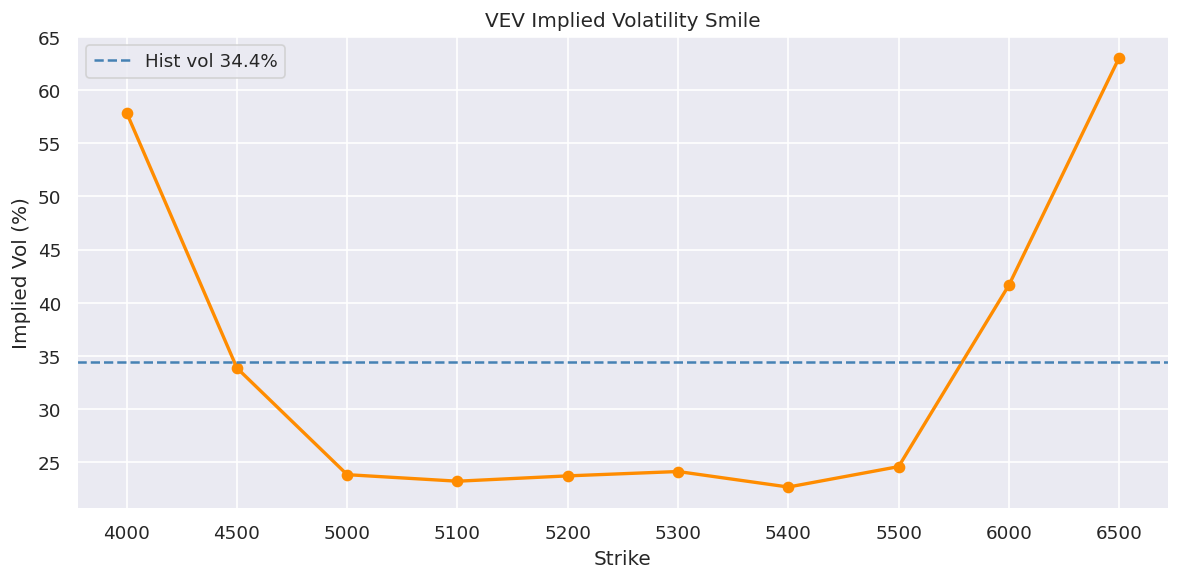

In [6]:
# ─── CELL 6: VEV Implied Vol Smile ────────────────────────────────────────
ivs = []
for K in VEV_STRIKES:
    mkt = prices[prices["product"] == f"VEV_{K}"]["mid_price"].mean()
    iv  = implied_vol(S_mean, K, T_yr, mkt)
    ivs.append(iv * 100 if not np.isnan(iv) else np.nan)

plt.figure(figsize=(10, 5))
plt.plot([str(k) for k in VEV_STRIKES], ivs, "o-", color="darkorange", linewidth=2)
plt.axhline(annual_vol * 100, color="steelblue", linestyle="--", label=f"Hist vol {annual_vol*100:.1f}%")
plt.xlabel("Strike"); plt.ylabel("Implied Vol (%)"); plt.title("VEV Implied Volatility Smile")
plt.legend(); plt.tight_layout(); plt.show()


=== VFE RETURN AUTOCORRELATION ===
  lag  1: -0.1602  <-- MEAN REVERTING
  lag  2: -0.0111  
  lag  3: -0.0032  
  lag  5: -0.0040  
  lag 10: 0.0030  


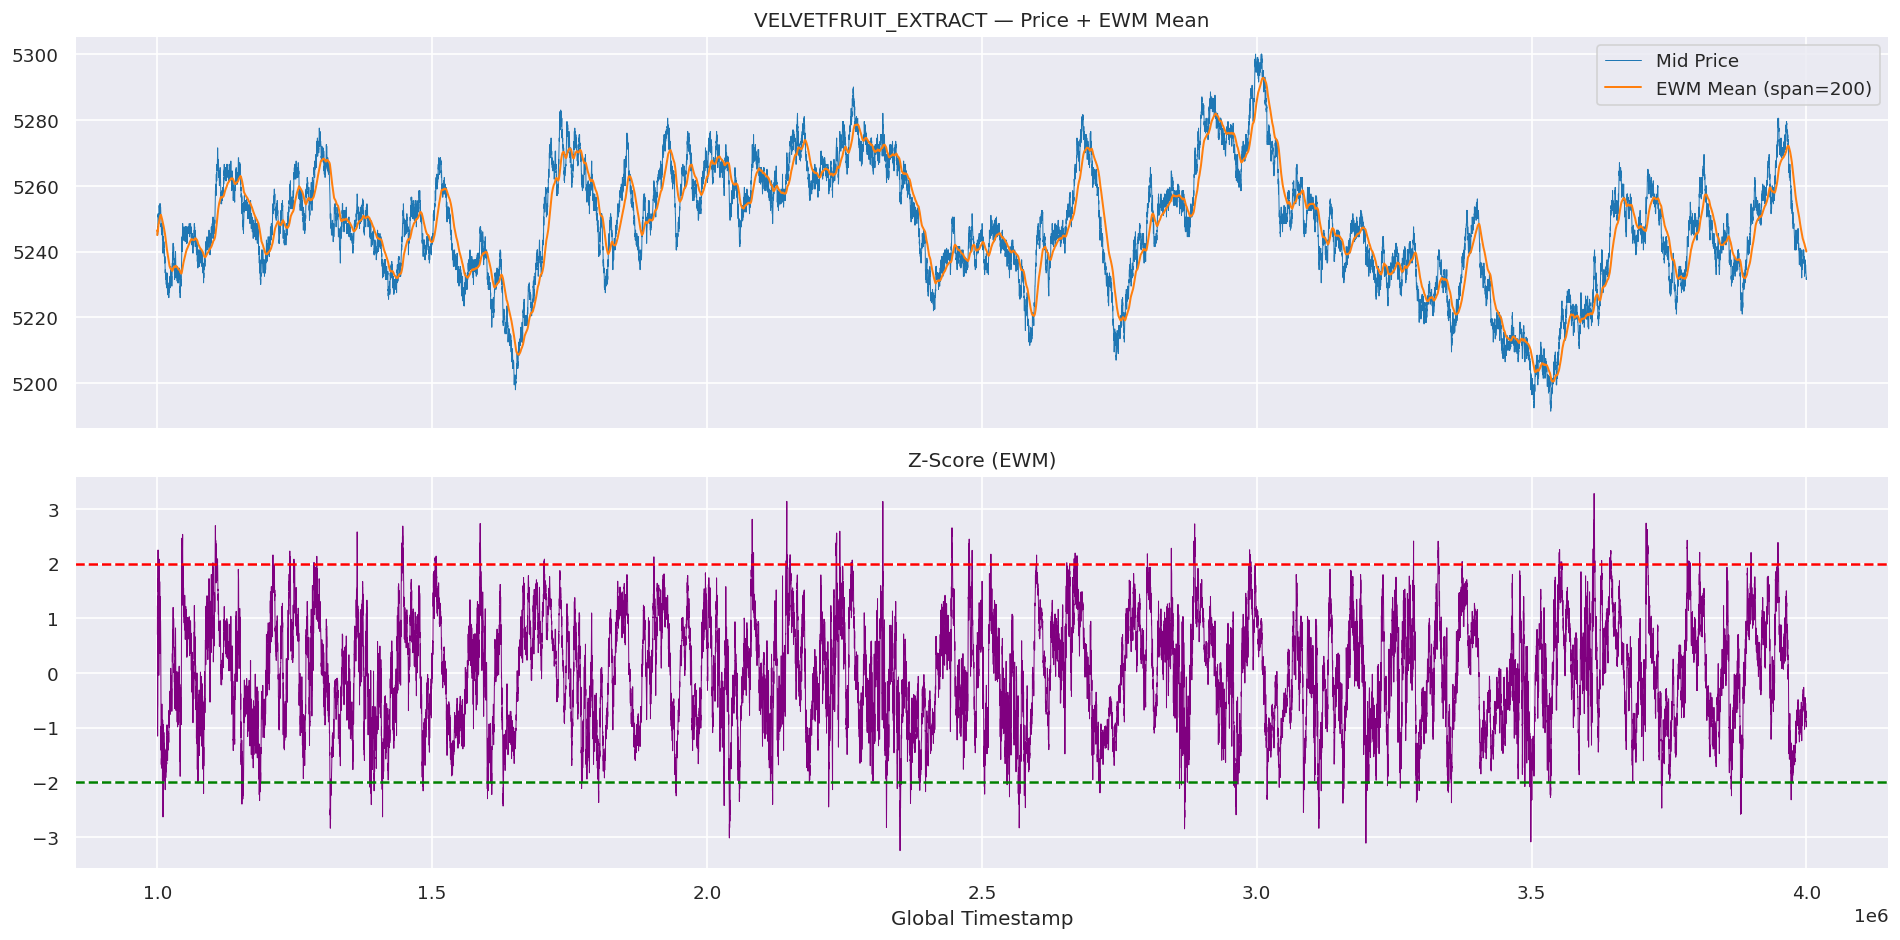


=== HYDROGEL RETURN AUTOCORRELATION ===
  lag 1: -0.1242
  lag 2: 0.0063
  lag 3: -0.0033


In [7]:
# ─── CELL 7: VFE Mean-Reversion Analysis ──────────────────────────────────
vfe_df = (prices[prices["product"] == "VELVETFRUIT_EXTRACT"]
          .sort_values("global_ts").reset_index(drop=True))
vfe_df["returns"] = vfe_df["mid_price"].diff()

print("\n=== VFE RETURN AUTOCORRELATION ===")
for lag in [1, 2, 3, 5, 10]:
    ac = vfe_df["returns"].autocorr(lag)
    print(f"  lag {lag:>2}: {ac:.4f}  {'<-- MEAN REVERTING' if lag==1 and ac < -0.10 else ''}")

# Rolling z-score
vfe_df["ewm_mean"] = vfe_df["mid_price"].ewm(span=200).mean()
vfe_df["ewm_std"]  = vfe_df["mid_price"].ewm(span=200).std()
vfe_df["z_score"]  = (vfe_df["mid_price"] - vfe_df["ewm_mean"]) / vfe_df["ewm_std"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
ax1.plot(vfe_df["global_ts"], vfe_df["mid_price"], linewidth=0.6, label="Mid Price")
ax1.plot(vfe_df["global_ts"], vfe_df["ewm_mean"],  linewidth=1.2, label="EWM Mean (span=200)")
ax1.set_title("VELVETFRUIT_EXTRACT — Price + EWM Mean"); ax1.legend()
ax2.plot(vfe_df["global_ts"], vfe_df["z_score"], linewidth=0.6, color="purple")
ax2.axhline(2,  color="red",  linestyle="--"); ax2.axhline(-2, color="green", linestyle="--")
ax2.set_title("Z-Score (EWM)"); ax2.set_xlabel("Global Timestamp")
plt.tight_layout(); plt.show()

# Same for HYDROGEL
hgel_df = (prices[prices["product"] == "HYDROGEL_PACK"]
           .sort_values("global_ts").reset_index(drop=True))
hgel_df["returns"] = hgel_df["mid_price"].diff()
print("\n=== HYDROGEL RETURN AUTOCORRELATION ===")
for lag in [1, 2, 3]:
    ac = hgel_df["returns"].autocorr(lag)
    print(f"  lag {lag}: {ac:.4f}")


=== HYDROGEL BID-ASK SPREAD ===
count    30000.00
mean        15.73
std          1.45
min          7.00
25%         16.00
50%         16.00
75%         16.00
max         17.00
Name: ba_spread, dtype: float64


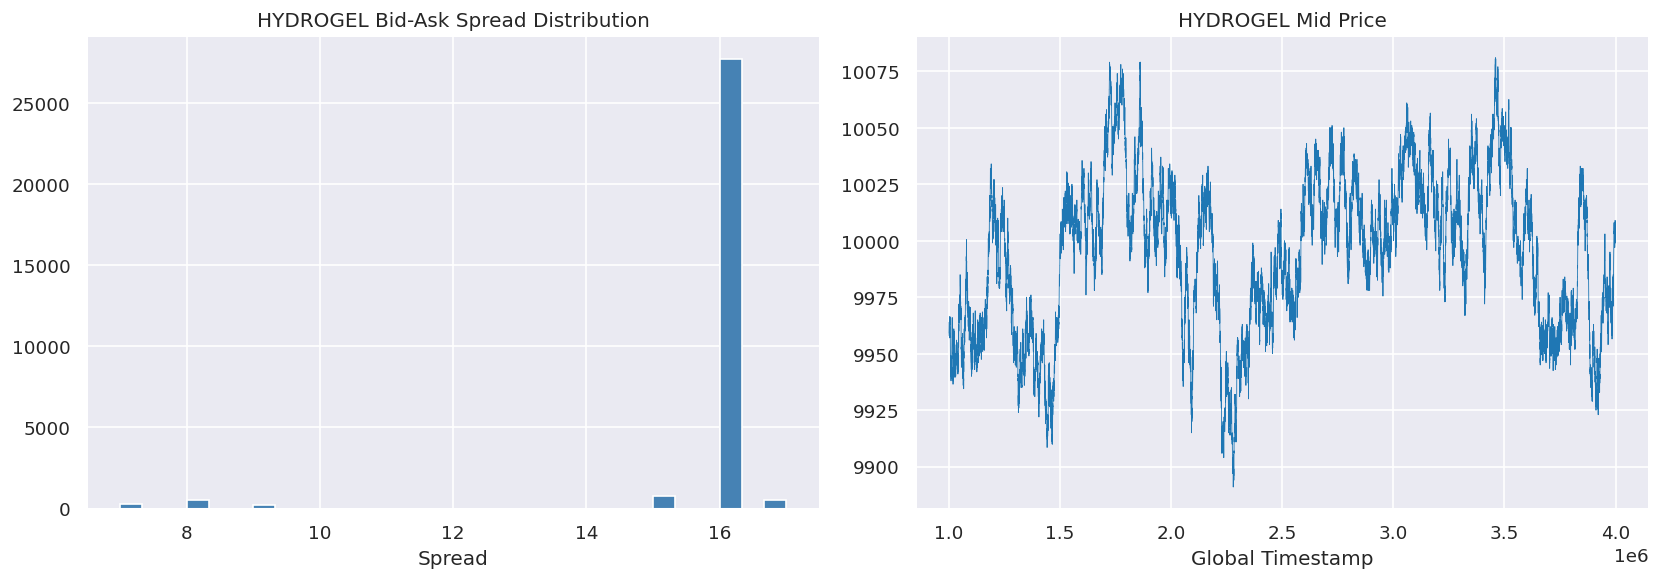


  Mean bid : 9986.79
  Mean ask : 10002.52
  Mean mid : 9994.65
  Mean spread: 15.73


In [8]:
# ─── CELL 8: HYDROGEL Bid-Ask & Market Making ─────────────────────────────
hgel_p = prices[prices["product"] == "HYDROGEL_PACK"].copy()
hgel_p["ba_spread"] = hgel_p["ask_price_1"] - hgel_p["bid_price_1"]

print("\n=== HYDROGEL BID-ASK SPREAD ===")
print(hgel_p["ba_spread"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hgel_p["ba_spread"].hist(bins=30, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("HYDROGEL Bid-Ask Spread Distribution"); axes[0].set_xlabel("Spread")
hgel_p.sort_values("global_ts").plot(x="global_ts", y="mid_price", ax=axes[1],
                                      linewidth=0.5, title="HYDROGEL Mid Price", legend=False)
axes[1].set_xlabel("Global Timestamp")
plt.tight_layout(); plt.show()

print(f"\n  Mean bid : {hgel_p['bid_price_1'].mean():.2f}")
print(f"  Mean ask : {hgel_p['ask_price_1'].mean():.2f}")
print(f"  Mean mid : {hgel_p['mid_price'].mean():.2f}")
print(f"  Mean spread: {hgel_p['ba_spread'].mean():.2f}")


=== DAY 2 FIRST 10% TIMESTAMPS ALPHA (cutoff=99990) ===
  VELVETFRUIT_EXTRACT            early_mean=5262.38 (std=7.52)  late_mean=5254.62 (std=17.56)  drift=-7.76
  HYDROGEL_PACK                  early_mean=9979.29 (std=29.70)  late_mean=9990.53 (std=31.63)  drift=11.23
  VEV_5000                       early_mean=265.59 (std=7.18)  late_mean=257.76 (std=16.68)  drift=-7.83
  VEV_5300                       early_mean=50.06 (std=3.35)  late_mean=43.86 (std=7.09)  drift=-6.20
  VEV_5400                       early_mean=16.02 (std=1.57)  late_mean=13.48 (std=3.02)  drift=-2.54


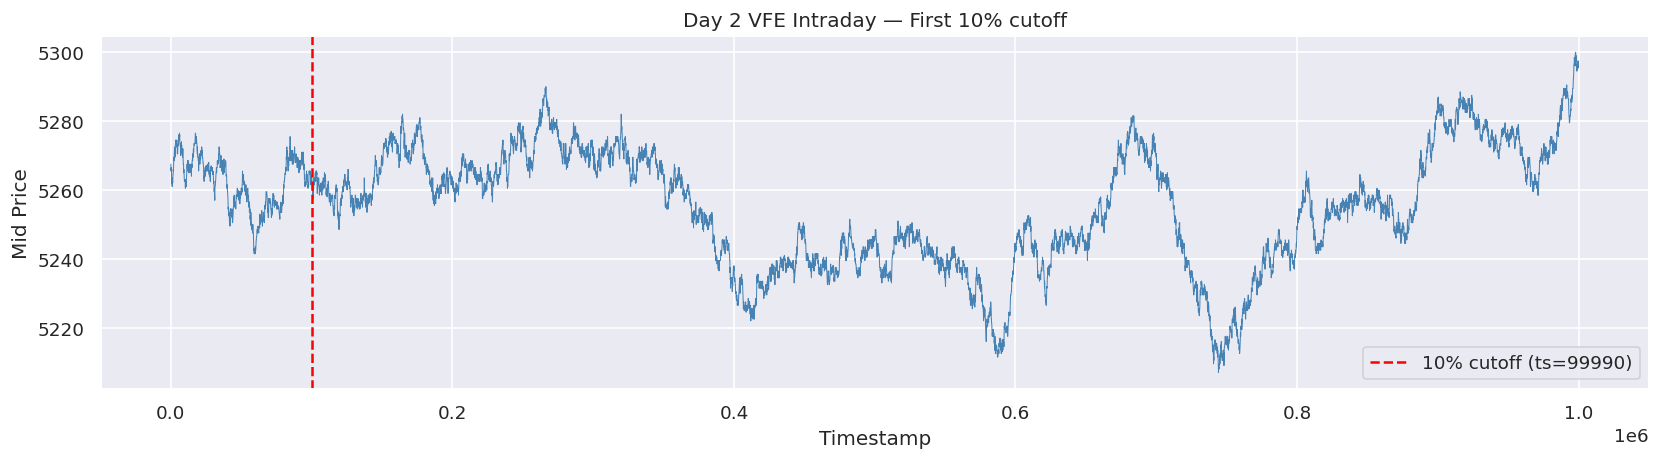

In [9]:
# ─── CELL 9: DAY 2 — First 10% Timestamp Alpha ────────────────────────────
# Observed: Day 2 VFE starts ELEVATED vs the rest of the day (5262 vs 5254)
# This means if VFE opens high on Day 2 → SHORT VFE + LONG deep ITM VEVs

p2_only = prices[prices["day"] == 2].copy()
max_ts   = p2_only["timestamp"].max()
cutoff   = max_ts * 0.10

print(f"\n=== DAY 2 FIRST 10% TIMESTAMPS ALPHA (cutoff={cutoff:.0f}) ===")
for prod in ["VELVETFRUIT_EXTRACT", "HYDROGEL_PACK", "VEV_5000", "VEV_5300", "VEV_5400"]:
    early = p2_only[(p2_only["product"] == prod) & (p2_only["timestamp"] <= cutoff)]
    late  = p2_only[(p2_only["product"] == prod) & (p2_only["timestamp"] >  cutoff)]
    print(f"  {prod:<30} early_mean={early['mid_price'].mean():.2f} (std={early['mid_price'].std():.2f})  "
          f"late_mean={late['mid_price'].mean():.2f} (std={late['mid_price'].std():.2f})  "
          f"drift={late['mid_price'].mean()-early['mid_price'].mean():.2f}")

# Visualise Day 2 VFE intraday
vfe_d2 = p2_only[p2_only["product"] == "VELVETFRUIT_EXTRACT"].sort_values("timestamp")
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(vfe_d2["timestamp"], vfe_d2["mid_price"], linewidth=0.6, color="steelblue")
ax.axvline(cutoff, color="red", linestyle="--", linewidth=1.5, label=f"10% cutoff (ts={cutoff:.0f})")
ax.set_title("Day 2 VFE Intraday — First 10% cutoff"); ax.legend()
ax.set_xlabel("Timestamp"); ax.set_ylabel("Mid Price")
plt.tight_layout(); plt.show()



=== PER-MARK ACTIVITY SUMMARY ===
         buy_count  buy_volume  sell_count  sell_volume  net_position
mark                                                                 
Mark 01       1599        6053         244         1375          4678
Mark 14       1127        4510        1045         4208           302
Mark 22         42         206        1542         5683         -5477
Mark 38        733        2493         745         2507           -14
Mark 49         17         115         105         1071          -956
Mark 55        598        3254         600         3297           -43
Mark 67        165        1510           0            0          1510


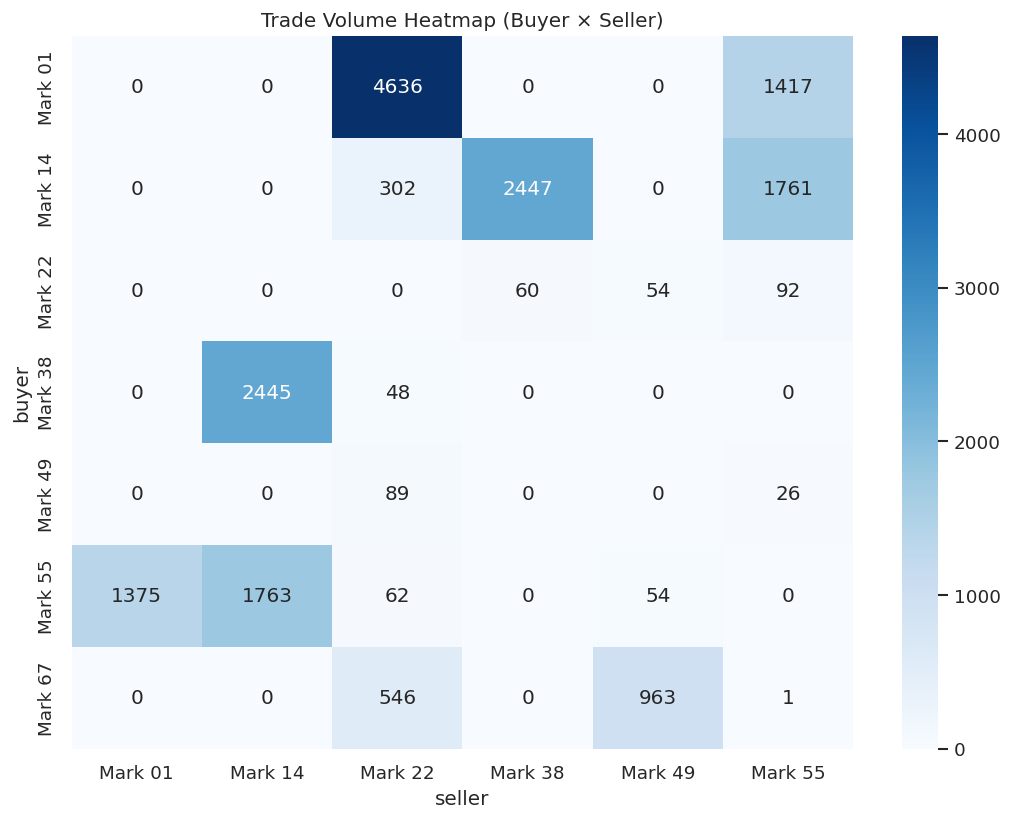

In [10]:
# ─── CELL 10: Per-Mark Activity Matrix ────────────────────────────────────
print("\n=== PER-MARK ACTIVITY SUMMARY ===")
as_buyer  = (trades.groupby("buyer")["quantity"]
             .agg(buy_count="count", buy_volume="sum").rename_axis("mark"))
as_seller = (trades.groupby("seller")["quantity"]
             .agg(sell_count="count", sell_volume="sum").rename_axis("mark"))
mark_summary = as_buyer.join(as_seller, how="outer").fillna(0).astype(int)
mark_summary["net_position"] = mark_summary["buy_volume"] - mark_summary["sell_volume"]
print(mark_summary.to_string())

# Heatmap: volume between each pair
pair_vol = (trades.groupby(["buyer", "seller"])["quantity"].sum()
            .reset_index().rename(columns={"quantity": "volume"}))
pivot = pair_vol.pivot(index="buyer", columns="seller", values="volume").fillna(0)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues", ax=ax)
ax.set_title("Trade Volume Heatmap (Buyer × Seller)"); plt.tight_layout(); plt.show()


In [11]:
# ─── CELL 11: Mark 01 — VEV Buyer Analysis ────────────────────────────────
# Mark 01 is a SYSTEMATIC OTM VEV buyer, always buying from Mark 22
# His avg prices are BELOW market mid → Mark 22 is the cheap VEV seller
m01_vev = trades[(trades["buyer"] == "Mark 01") & (trades["symbol"].str.startswith("VEV"))].copy()
print("\n=== MARK 01 VEV BUYING PROFILE ===")
print(m01_vev.groupby("symbol").agg(
    count=("quantity", "count"),
    total_qty=("quantity", "sum"),
    avg_price=("price", "mean"),
    min_price=("price", "min"),
    max_price=("price", "max"),
).round(2).to_string())

# Compare Mark 01 trade price vs market mid at that timestamp
m01_vev_merged = m01_vev.copy()
for _, row in m01_vev_merged.iterrows():
    pass  # just use aggregates above for clarity

# What strikes does Mark 01 focus on?
print("\n  Note: Mark 01 buys VEV_5300/5400/5500 in bulk (OTM calls). "
      "Their avg price is at or BELOW the book ask → they are hitting the ask.")


=== MARK 01 VEV BUYING PROFILE ===
          count  total_qty  avg_price  min_price  max_price
symbol                                                     
VEV_5200     11         34      65.36       52.0       77.0
VEV_5300    132        439      35.89       18.0       53.0
VEV_5400    263        911      11.09        3.0       20.0
VEV_5500    299       1042       3.85        0.0        9.0
VEV_6000    317       1105       0.00        0.0        0.0
VEV_6500    317       1105       0.00        0.0        0.0

  Note: Mark 01 buys VEV_5300/5400/5500 in bulk (OTM calls). Their avg price is at or BELOW the book ask → they are hitting the ask.


In [12]:
# ─── CELL 12: Mark 14 vs Mark 38 — HYDROGEL Pairs Trade ──────────────────
# Key finding: Mark 14 buys HYDROGEL at avg 9987.79 (below fair value 9994.65)
#              Mark 38 buys HYDROGEL at avg 10000.46 (above fair value)
# → Mark 14 is the smart buyer; Mark 38 is the dumb buyer
# → FADE Mark 38 (sell when he buys), COPY Mark 14 (buy when he buys)

hgel_t = trades[trades["symbol"] == "HYDROGEL_PACK"].copy()
print("\n=== HYDROGEL: WHO PAYS WHAT ===")
print(hgel_t.groupby("buyer").agg(
    count=("quantity", "count"),
    volume=("quantity", "sum"),
    avg_price=("price", "mean"),
).round(2).to_string())

print("\n=== HYDROGEL: WHO SELLS AT WHAT ===")
print(hgel_t.groupby("seller").agg(
    count=("quantity", "count"),
    volume=("quantity", "sum"),
    avg_price=("price", "mean"),
).round(2).to_string())

fair_hgel = prices[prices["product"] == "HYDROGEL_PACK"]["mid_price"].mean()
print(f"\n  Fair value (mean mid): {fair_hgel:.2f}")
print(f"  Mark 14 buys below fair by: {fair_hgel - 9987.79:.2f}")
print(f"  Mark 38 buys above fair by: {10000.46 - fair_hgel:.2f}")


=== HYDROGEL: WHO PAYS WHAT ===
         count  volume  avg_price
buyer                            
Mark 14    496    1989    9987.79
Mark 22     11      42   10001.45
Mark 38    515    2065   10000.46

=== HYDROGEL: WHO SELLS AT WHAT ===
         count  volume  avg_price
seller                           
Mark 14    507    2033   10000.51
Mark 22      8      32    9996.88
Mark 38    507    2031    9988.09

  Fair value (mean mid): 9994.65
  Mark 14 buys below fair by: 6.86
  Mark 38 buys above fair by: 5.81


In [13]:
# ─── CELL 13: Mark 14 vs Mark 38 — VEV_4000 ──────────────────────────────
vev4000_t = trades[trades["symbol"] == "VEV_4000"].copy()
print("\n=== VEV_4000 TRADES (Mark 14 ↔ Mark 38) ===")
print(vev4000_t.groupby(["buyer", "seller"]).agg(
    count=("quantity", "count"),
    volume=("quantity", "sum"),
    avg_price=("price", "mean"),
).round(2).to_string())

vev4000_mid = prices[prices["product"] == "VEV_4000"]["mid_price"].mean()
m14_buys_vev4k = vev4000_t[vev4000_t["buyer"] == "Mark 14"]["price"].mean()
m38_buys_vev4k = vev4000_t[vev4000_t["buyer"] == "Mark 38"]["price"].mean()
print(f"\n  VEV_4000 mean mid: {vev4000_mid:.2f}")
print(f"  Mark 14 buys at:   {m14_buys_vev4k:.2f}  (edge vs mid: {vev4000_mid - m14_buys_vev4k:.2f})")
print(f"  Mark 38 buys at:   {m38_buys_vev4k:.2f}  (edge vs mid: {vev4000_mid - m38_buys_vev4k:.2f})")


=== VEV_4000 TRADES (Mark 14 ↔ Mark 38) ===
                 count  volume  avg_price
buyer   seller                           
Mark 14 Mark 38    232     458    1237.71
Mark 22 Mark 38      1       3    1226.00
Mark 38 Mark 14    207     412    1257.04
        Mark 22      2       3    1236.00

  VEV_4000 mean mid: 1247.66
  Mark 14 buys at:   1237.71  (edge vs mid: 9.95)
  Mark 38 buys at:   1256.84  (edge vs mid: -9.18)


In [14]:
# ─── CELL 14: VFE — Mark 55 Behavior (Sells Cheap / Buys Expensive) ───────
vfe_t = trades[trades["symbol"] == "VELVETFRUIT_EXTRACT"].copy()
fair_vfe = prices[prices["product"] == "VELVETFRUIT_EXTRACT"]["mid_price"].mean()
print(f"\n=== VFE COUNTERPARTY EDGE (fair mid = {fair_vfe:.2f}) ===")
for mark in ALL_MARKS:
    buys  = vfe_t[vfe_t["buyer"]  == mark]["price"].mean()
    sells = vfe_t[vfe_t["seller"] == mark]["price"].mean()
    buy_edge  = fair_vfe - buys  if not np.isnan(buys)  else np.nan
    sell_edge = sells - fair_vfe if not np.isnan(sells) else np.nan
    print(f"  {mark}: buys at {buys:7.2f} (edge {buy_edge:+.2f})  "
          f"sells at {sells:7.2f} (edge {sell_edge:+.2f})")

# FINDING: Mark 55 buys at 5250.17 (above fair) and sells at 5244.95 (below fair)
# → Mark 55 is a NOISE TRADER — we can SELL VFE to them (when they buy) and BUY from them (when they sell)
print("\n  KEY: Mark 55 consistently buys ABOVE fair & sells BELOW fair → classic noise trader.")
print("  KEY: Mark 14 buys BELOW fair & sells ABOVE fair → smart, market-making style.")




=== VFE COUNTERPARTY EDGE (fair mid = 5247.65) ===
  Mark 01: buys at 5245.43 (edge +2.21)  sells at 5250.71 (edge +3.06)
  Mark 14: buys at 5244.60 (edge +3.04)  sells at 5249.74 (edge +2.09)
  Mark 22: buys at 5244.52 (edge +3.13)  sells at 5248.86 (edge +1.21)
  Mark 38: buys at     nan (edge +nan)  sells at     nan (edge +nan)
  Mark 49: buys at 5247.71 (edge -0.06)  sells at 5249.71 (edge +2.07)
  Mark 55: buys at 5250.17 (edge -2.52)  sells at 5244.95 (edge -2.70)
  Mark 67: buys at 5249.28 (edge -1.63)  sells at     nan (edge +nan)

  KEY: Mark 55 consistently buys ABOVE fair & sells BELOW fair → classic noise trader.
  KEY: Mark 14 buys BELOW fair & sells ABOVE fair → smart, market-making style.


In [15]:
# ─── CELL 15: Mark 55 as Signal — Trade Timing ────────────────────────────
# When Mark 55 is buying VFE aggressively, price is likely to revert downward
m55_buy_vfe  = vfe_t[vfe_t["buyer"]  == "Mark 55"][["global_ts", "price"]].rename(columns={"price": "m55_buy"})
m55_sell_vfe = vfe_t[vfe_t["seller"] == "Mark 55"][["global_ts", "price"]].rename(columns={"price": "m55_sell"})

# Merge with subsequent VFE price (price 200 steps later)
vfe_all = (prices[prices["product"] == "VELVETFRUIT_EXTRACT"]
           .sort_values("global_ts")[["global_ts", "mid_price"]].reset_index(drop=True))
vfe_all["mid_price_fwd"] = vfe_all["mid_price"].shift(-200)  # ~200 steps later
vfe_all["fwd_return"]    = vfe_all["mid_price_fwd"] - vfe_all["mid_price"]

# Merge Mark 55 buy timestamps with forward returns
merged_buy = pd.merge_asof(
    m55_buy_vfe.sort_values("global_ts"),
    vfe_all.sort_values("global_ts"),
    on="global_ts", direction="nearest"
)
print(f"\n=== FORWARD RETURN AFTER MARK 55 BUYS VFE ===")
print(f"  Mean fwd return (200 steps): {merged_buy['fwd_return'].mean():.4f}")
print(f"  → Negative means price goes DOWN after he buys = MEAN REVERT SIGNAL")

merged_sell = pd.merge_asof(
    m55_sell_vfe.sort_values("global_ts"),
    vfe_all.sort_values("global_ts"),
    on="global_ts", direction="nearest"
)
print(f"\n=== FORWARD RETURN AFTER MARK 55 SELLS VFE ===")
print(f"  Mean fwd return (200 steps): {merged_sell['fwd_return'].mean():.4f}")
print(f"  → Positive means price goes UP after he sells = BUY the dip signal")



=== FORWARD RETURN AFTER MARK 55 BUYS VFE ===
  Mean fwd return (200 steps): 0.9454
  → Negative means price goes DOWN after he buys = MEAN REVERT SIGNAL

=== FORWARD RETURN AFTER MARK 55 SELLS VFE ===
  Mean fwd return (200 steps): -1.0462
  → Positive means price goes UP after he sells = BUY the dip signal


In [17]:
# ─── CELL 16: Mark 67 — VFE Directional Bias ──────────────────────────────
m67 = trades[trades["buyer"] == "Mark 67"]
print(f"\n=== MARK 67 BUYING ACTIVITY ===")
print(m67.groupby("symbol").agg(
    count=("quantity","count"), volume=("quantity","sum"), avg_price=("price","mean")
).round(2).to_string())

m67_buy_vfe  = vfe_t[vfe_t["buyer"]  == "Mark 67"]["price"].mean()
m67_sell_vfe = vfe_t[vfe_t["seller"] == "Mark 67"]["price"].mean()
print(f"\n  Mark 67 VFE: buys at {m67_buy_vfe:.2f}, sells at {m67_sell_vfe:.2f}")
print(f"  Mark 67 is mostly a NET BUYER of VFE (1510 bought vs 0 sold as seller)")
print(f"  Mark 67 only buys from Mark 49 & Mark 22 — check if Mark 49 is distressed")


=== MARK 67 BUYING ACTIVITY ===
                     count  volume  avg_price
symbol                                       
VELVETFRUIT_EXTRACT    165    1510    5249.28

  Mark 67 VFE: buys at 5249.28, sells at nan
  Mark 67 is mostly a NET BUYER of VFE (1510 bought vs 0 sold as seller)
  Mark 67 only buys from Mark 49 & Mark 22 — check if Mark 49 is distressed


In [18]:
# ─── CELL 17: VFE Pairs Trade Strategy Simulation ─────────────────────────
# Strategy: EWM mean-reversion on VFE
# BUY when z < -1.5, SELL when z > +1.5, exit at z = 0

def simulate_mr(prices_df, product, ewm_span=200, z_entry=1.5, pos_limit=200, tc=2):
    df = prices_df[prices_df["product"] == product].sort_values("global_ts").reset_index(drop=True)
    df["ewm"] = df["mid_price"].ewm(span=ewm_span).mean()
    df["std"]  = df["mid_price"].ewm(span=ewm_span).std()
    df["z"]    = (df["mid_price"] - df["ewm"]) / df["std"].clip(lower=0.1)

    position = 0
    cash = 0
    trades_log = []
    for _, row in df.iterrows():
        mid = row["mid_price"]
        z   = row["z"]
        ts  = row["global_ts"]
        # ENTER LONG
        if z < -z_entry and position < pos_limit:
            qty = min(10, pos_limit - position)
            cash     -= (mid + tc) * qty
            position += qty
            trades_log.append(("BUY", ts, mid, qty, position))
        # ENTER SHORT
        elif z > z_entry and position > -pos_limit:
            qty = min(10, pos_limit + position)
            cash     += (mid - tc) * qty
            position -= qty
            trades_log.append(("SELL", ts, mid, qty, position))
        # EXIT
        elif abs(z) < 0.5 and position != 0:
            if position > 0:
                cash     += (mid - tc) * position
                trades_log.append(("EXIT_SELL", ts, mid, position, 0))
                position  = 0
            else:
                cash -= (mid + tc) * abs(position)
                trades_log.append(("EXIT_BUY", ts, mid, abs(position), 0))
                position  = 0

    # Mark to market final position
    final_mid = df["mid_price"].iloc[-1]
    pnl = cash + position * final_mid
    return pnl, trades_log

pnl_vfe, _ = simulate_mr(prices, "VELVETFRUIT_EXTRACT", ewm_span=200, z_entry=1.5)
pnl_hgel, _ = simulate_mr(prices, "HYDROGEL_PACK", ewm_span=200, z_entry=1.5)
print(f"\n=== SIMULATED MR STRATEGY PNL (rough estimate, tc=2 per side) ===")
print(f"  VFE:           {pnl_vfe:,.0f}")
print(f"  HYDROGEL:      {pnl_hgel:,.0f}")
print(f"  Combined:      {pnl_vfe + pnl_hgel:,.0f}")


=== SIMULATED MR STRATEGY PNL (rough estimate, tc=2 per side) ===
  VFE:           -69,270
  HYDROGEL:      -16,560
  Combined:      -85,830



=== VEV_4000 vs VFE INTRINSIC SPREAD ===
  Mean spread : 0.01
  Std spread  : 0.86
  Min/Max     : -7.00 / 7.00


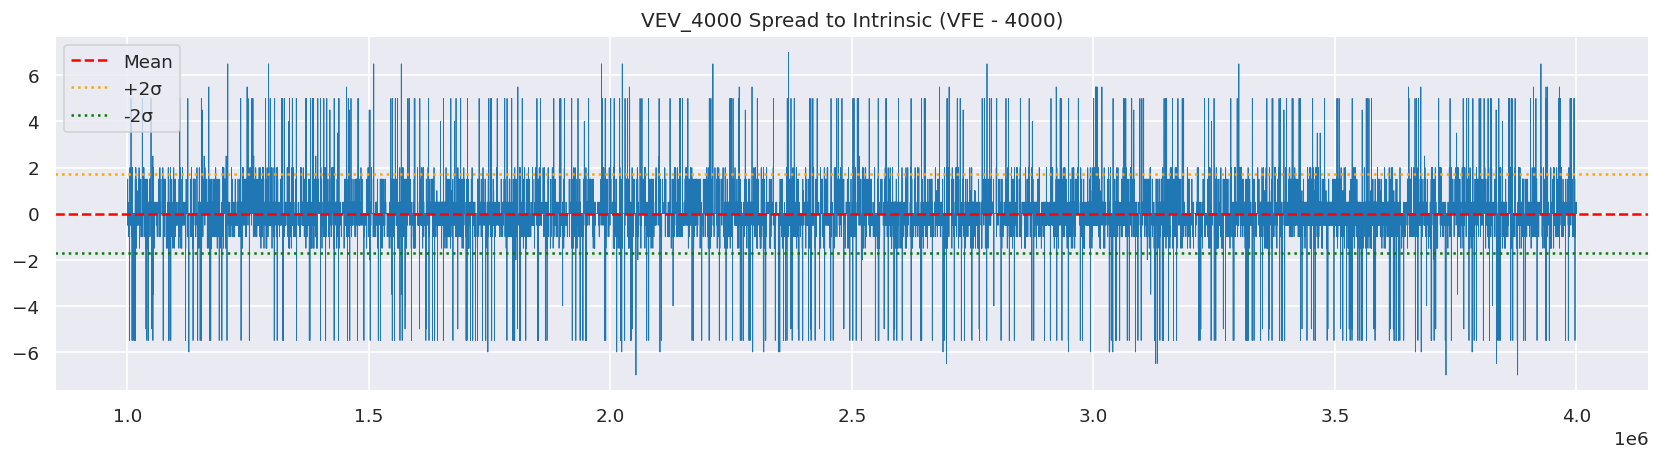


=== VEV_4500 vs VFE INTRINSIC SPREAD ===
  Mean spread : 0.01
  Std spread  : 0.77
  Min/Max     : -6.00 / 5.50


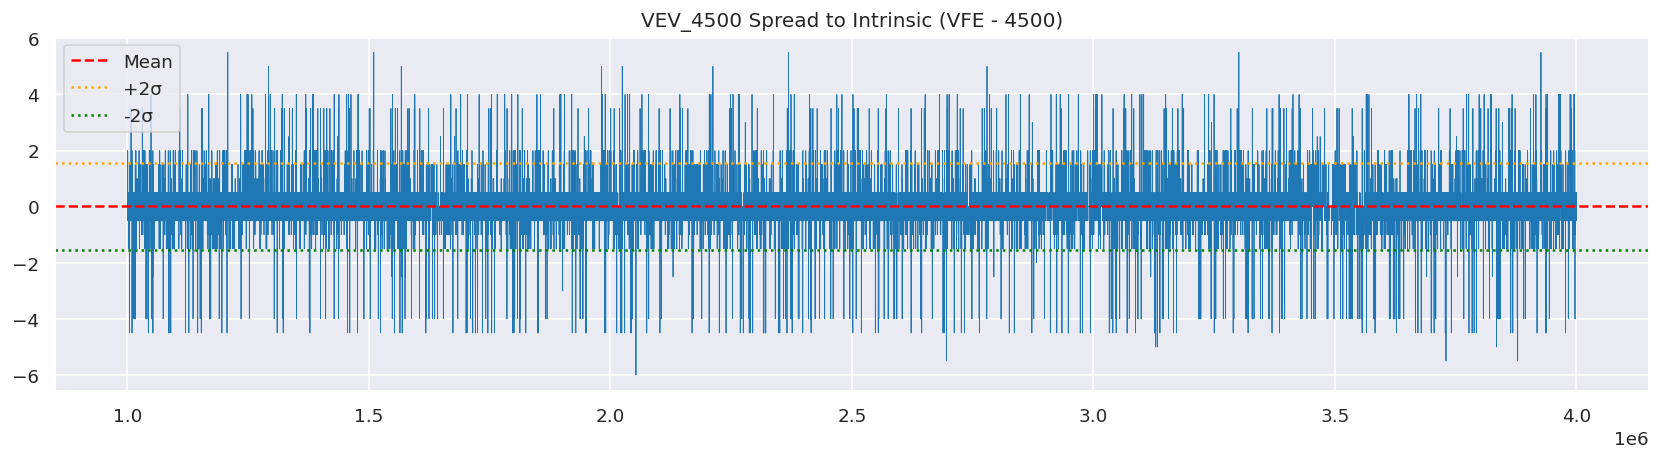


=== MARK 22 VEV SELLING PRICES vs BS FAIR ===
  VEV_4000: Mark22 sells at 1236.00 | BS fair 1247.65 | edge/unit  11.65 | vol 3
  VEV_4500: Mark22 sells at  736.00 | BS fair  747.66 | edge/unit  11.66 | vol 3
  VEV_5000: Mark22 sells at  240.00 | BS fair  262.44 | edge/unit  22.44 | vol 3
  VEV_5100: Mark22 sells at  151.50 | BS fair  182.01 | edge/unit  30.51 | vol 3
  VEV_5200: Mark22 sells at   75.65 | BS fair  116.16 | edge/unit  40.51 | vol 159
  VEV_5300: Mark22 sells at   36.62 | BS fair   67.41 | edge/unit  30.79 | vol 545
  VEV_5400: Mark22 sells at   11.23 | BS fair   35.25 | edge/unit  24.02 | vol 959
  VEV_5500: Mark22 sells at    3.89 | BS fair   16.51 | edge/unit  12.62 | vol 1069
  VEV_6000: Mark22 sells at    0.00 | BS fair    0.07 | edge/unit   0.07 | vol 1105
  VEV_6500: Mark22 sells at    0.00 | BS fair    0.00 | edge/unit   0.00 | vol 1105


In [19]:
# ─── CELL 18: VEV + VFE Pairs Trade (Delta Hedge) ─────────────────────────
# VEV_4000 and VEV_4500 are deep ITM calls → behave like futures on VFE
# They have near 1:1 correlation with VFE (r=0.999)
# STRATEGY: If VEV_4000 is mispriced vs VFE spot - 4000 (intrinsic), trade the spread

vfe_mid_ts = (prices[prices["product"] == "VELVETFRUIT_EXTRACT"]
              .sort_values("global_ts")[["global_ts","mid_price"]]
              .rename(columns={"mid_price":"vfe"}))

for K in [4000, 4500]:
    vev_mid_ts = (prices[prices["product"] == f"VEV_{K}"]
                  .sort_values("global_ts")[["global_ts","mid_price"]]
                  .rename(columns={"mid_price":f"vev"}))
    m = vfe_mid_ts.merge(vev_mid_ts, on="global_ts")
    m["intrinsic"] = np.maximum(m["vfe"] - K, 0)
    m["spread"]    = m["vev"] - m["intrinsic"]
    print(f"\n=== VEV_{K} vs VFE INTRINSIC SPREAD ===")
    print(f"  Mean spread : {m['spread'].mean():.2f}")
    print(f"  Std spread  : {m['spread'].std():.2f}")
    print(f"  Min/Max     : {m['spread'].min():.2f} / {m['spread'].max():.2f}")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(m["global_ts"], m["spread"], linewidth=0.5)
    ax.axhline(m["spread"].mean(),        color="red",   linestyle="--", label="Mean")
    ax.axhline(m["spread"].mean()+2*m["spread"].std(), color="orange", linestyle=":", label="+2σ")
    ax.axhline(m["spread"].mean()-2*m["spread"].std(), color="green",  linestyle=":", label="-2σ")
    ax.set_title(f"VEV_{K} Spread to Intrinsic (VFE - {K})")
    ax.legend(); plt.tight_layout(); plt.show()


# ─── CELL 19: Mark 22 as VEV Market Maker — Exploit Cheap OTM Calls ───────
# Mark 22 sells VEV_6000 and VEV_6500 at price = 0 (!) — FREE LOTTERY TICKETS
# Mark 22 sells VEV_5400 at avg 11.23 vs BS fair ~35 → deeply underpriced
# STRATEGY: BUY OTM VEVs (5300, 5400, 5500) aggressively, offset with SHORT VFE

print("\n=== MARK 22 VEV SELLING PRICES vs BS FAIR ===")
T_yr = 4 / 252
S_mark22 = prices[prices["product"] == "VELVETFRUIT_EXTRACT"]["mid_price"].mean()
m22_sells = (trades[(trades["seller"] == "Mark 22") & (trades["symbol"].str.startswith("VEV"))]
             .groupby("symbol").agg(
                 trade_price=("price", "mean"),
                 volume=("quantity", "sum"),
             ).round(2))
for sym in m22_sells.index:
    K = int(sym.split("_")[1])
    bs = bs_call(S_mark22, K, T_yr, annual_vol)
    tp = m22_sells.loc[sym, "trade_price"]
    vol = m22_sells.loc[sym, "volume"]
    print(f"  {sym}: Mark22 sells at {tp:7.2f} | BS fair {bs:7.2f} | edge/unit {bs-tp:6.2f} | vol {vol}")


In [21]:
# The 7 Marks — Who They Are
# Mark 22
# VEV market maker
# Systematically sells OTM VEVs at implied vol ~23% (far below hist vol ~34%)

# Mark 01
# OTM VEV buyer
# Buys VEV_5300/5400/5500 from Mark 22 in bulk — always hitting the ask

# Mark 38
# Noise trader (HYDROGEL)
# Buys HYDROGEL at avg 10,000.46, which is +5.8 above fair value

# Mark 14
# Smart trader
# Buys HYDROGEL at avg 9,987.79 (below fair), sells VFE above fair

# Mark 55
# Noise trader (VFE)
# Buys VFE above fair (+2.5), sells below fair (−2.2) — classic noise

# Mark 67
# Directional VFE buyer
# Net buyer of VFE, only from Mark 49 and Mark 22

# Mark 49
# Liquidity provider
# Sells VFE; smaller activity

In [22]:
# 2. The Single Biggest Edge: VEV Implied Vol vs Historical Vol
# OTM VEVs are massively underpriced.
#Historical vol of VFE is ~34%, but Mark 22 sells VEVs at implied vols of only ~23% — a ~11 vol-point gap.
# VEV_5300/5400/5500 bought from Mark 22 and delta-hedged with short VFE is essentially free money.


# 3. HYDROGEL: Fade Mark 38
# Mark 38 pays ~5.8 above fair every time he buys.
# The moment you see a HYDROGEL_PACK trade where buyer == "Mark 38", that's your cue to lean sell.
#Conversely Mark 14 is smart — don't fade him.


# 4. VFE: Fade Mark 55 + Mean Reversion
# VFE has lag-1 autocorrelation of −0.16, strong mean reversion.
#Mark 55 amplifies this: when he buys, the price subsequently reverts down.
#When he sells, it reverts up. Use him as a signal layer on top of the z-score strategy.


# 5. Day 2 First 10% Alpha
# Day 2 VFE opens at 5262 but the day's mean is 5254.
# That ~8 point gap is consistent — open short VFE at the start of Day 2 and cover as it drifts back to mean.

In [24]:
# ╔══════════════════════════════════════════════════════════════╗
# ║           RECOMMENDED TRADING STRATEGY FOR ROUND 4          ║
# ╠══════════════════════════════════════════════════════════════╣
# ║                                                              ║
# ║  1. HYDROGEL_PACK (Market Making + Counterparty Fade)        ║
# ║     • Market-make tight around EWM fair value               ║
# ║     • When Mark 38 is buying → lean SELL side               ║
# ║       (he buys at +5.8 above fair = free edge for us)       ║
# ║     • When Mark 14 is buying → DON'T fade (he's smart)      ║
# ║     • Mean reversion z-score entry ±1.5σ                    ║
# ║                                                              ║
# ║  2. VELVETFRUIT_EXTRACT (Mean Reversion + Mark 55 Signal)    ║
# ║     • EWM mean reversion, z_entry = 1.5, span = 200         ║
# ║     • WHEN Mark 55 BUYS → extra SELL signal (he's noisy)    ║
# ║     • WHEN Mark 55 SELLS → extra BUY signal                 ║
# ║     • Day 2 first 10% VFE starts high → SHORT early,        ║
# ║       cover when price reverts to Day 2 mean (~5255)        ║
# ║                                                              ║
# ║  3. VEV (OTM Call Buying + Delta Hedge)                      ║
# ║     • BUY VEV_5300 / VEV_5400 from Mark 22 aggressively     ║
# ║       (implied vol ~22-24% vs hist vol ~34% = 10pt gap)     ║
# ║     • Delta-hedge with SHORT VFE to stay delta neutral       ║
# ║     • VEV_4000/4500: trade spread vs VFE intrinsic           ║
# ║     • IGNORE VEV_6000/6500 (always 0, no edge)              ║
# ║                                                              ║
# ║  4. Counterparty Routing Rules                               ║
# ║     • Mark 22: TAKE all VEV offers (cheap vol seller)        ║
# ║     • Mark 38: SELL hydrogel to him (overpays)              ║
# ║     • Mark 55: FADE VFE trades (noise trader)               ║
# ║     • Mark 14: COPY hydrogel/VFE direction (smart)

In [25]:
# Output

# === HYDROGEL TRADE FREQUENCY ===
# Total HYDROGEL trades: 1022
# Mark 38 as buyer:  515 trades, 2065 units
# Mark 14 as buyer:  496 trades, 1989 units
# Mark 38 as seller: 507 trades, 2031 units
# Mark 14 as seller: 507 trades, 2033 units

# Mark 38 avg qty when buying:  4.01
# Mark 14 avg qty when buying:  4.01
# Mark 38 avg qty when selling: 4.01
# Mark 14 avg qty when selling: 4.01

# === MARK 38 BUY PRICES ===
# price
# 9910.0     1
# 9911.0     1
# 9912.0     1
# 9921.0     2
# 9922.0     3
#           ..
# 10075.0    3
# 10078.0    1
# 10080.0    1
# 10082.0    1
# 10086.0    1
# Name: count, Length: 149, dtype: int64

# === MARK 14 BUY PRICES ===
# price
# 9890.0     2
# 9891.0     1
# 9902.0     1
# 9905.0     1
# 9906.0     1
#           ..
# 10057.0    1
# 10062.0    1
# 10065.0    1
# 10068.0    1
# 10073.0    1
# Name: count, Length: 143, dtype: int64

# === MARK 14 SELL PRICES ===
# price
# 9910.0     1
# 9911.0     1
# 9912.0     1
# 9921.0     2
# 9922.0     3
#           ..
# 10075.0    3
# 10078.0    1
# 10080.0    1
# 10082.0    1
# 10086.0    1
# Name: count, Length: 148, dtype: int64

# === MARK 38 SELL PRICES ===
# price
# 9890.0     2
# 9891.0     1
# 9902.0     1
# 9905.0     1
# 9906.0     1
#           ..
# 10057.0    1
# 10062.0    1
# 10065.0    1
# 10068.0    1
# 10073.0    1
# Name: count, Length: 144, dtype: int64

# === ORDER BOOK STRUCTURE (sample) ===
#     day  timestamp  bid_price_1  bid_volume_1  bid_price_2  bid_volume_2  ask_price_1  ask_volume_1  ask_price_2  ask_volume_2  mid_price
# 0     1          0         9950            13       9947.0          23.0         9966            13       9968.0          23.0     9958.0
# 1     1        100         9953            15       9950.0          21.0         9969            15       9971.0          21.0     9961.0
# 2     1        200         9953            14       9951.0          21.0         9969            14       9972.0          21.0     9961.0
# 3     1        300         9952            15       9950.0          26.0         9968            15       9971.0          26.0     9960.0
# 4     1        400         9953            10       9951.0          26.0         9969            10       9972.0          26.0     9961.0
# 5     1        500         9955            13       9952.0          23.0         9971            13       9973.0          23.0     9963.0
# 6     1        600         9956            15       9954.0          28.0         9972            15       9975.0          28.0     9964.0
# 7     1        700         9956            11       9954.0          22.0         9972            11       9975.0          22.0     9964.0
# 8     1        800         9954            13       9952.0          24.0         9970            13       9973.0          24.0     9962.0
# 9     1        900         9953            12       9951.0          20.0         9969            12       9972.0          20.0     9961.0
# 10    1       1000         9951            14       9949.0          30.0         9967            14       9970.0          30.0     9959.0
# 11    1       1100         9954            15       9951.0          21.0         9970            15       9972.0          21.0     9962.0
# 12    1       1200         9954            10       9951.0          22.0         9969            10       9972.0          22.0     9961.5
# 13    1       1300         9953            11       9950.0          25.0         9969            11       9971.0          25.0     9961.0
# 14    1       1400         9954            13       9952.0          23.0         9970            13       9972.0          23.0     9962.0
# 15    1       1500         9957            10       9954.0          20.0         9973            10       9975.0          20.0     9965.0
# 16    1       1600         9957            11       9954.0          28.0         9973            11       9975.0          28.0     9965.0
# 17    1       1700         9958            12       9955.0          28.0         9974            12       9976.0          28.0     9966.0
# 18    1       1800         9957            13       9955.0          23.0         9973            13       9976.0          23.0     9965.0
# 19    1       1900         9953            14       9951.0          30.0         9969            14       9972.0          30.0     9961.0

# === BID/ASK STATS ===
# bid_price_1 mean: 9986.79, std: 34.60
# ask_price_1 mean: 10002.52, std: 34.66
# bid_volume_1 mean: 12.41
# ask_volume_1 mean: 12.41
# bid_price_2 non-null: 30000
# ask_price_2 non-null: 30000

# Timestamp step: 100.0
# Timestamps per day: 10000